In [200]:
print("all ok")

all ok


In [1]:
from dotenv import load_dotenv
load_dotenv()
import os
os.environ['GROQ_API_KEY'] = os.getenv("GROQ_API_KEY")

In [2]:
model="meta-llama/llama-4-maverick-17b-128e-instruct"

### Load the model

In [3]:
model="meta-llama/llama-4-maverick-17b-128e-instruct"
from langchain_groq import ChatGroq
llm=ChatGroq(model_name=model)
llm.invoke("hi")

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AIMessage(content='hi back at ya! is there something i can help you with or would you like to just chat?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 11, 'total_tokens': 33, 'completion_time': 0.03638189, 'prompt_time': 0.000948527, 'queue_time': 0.051444863, 'total_time': 0.037330417}, 'model_name': 'meta-llama/llama-4-maverick-17b-128e-instruct', 'system_fingerprint': 'fp_d2c1f7e199', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--b0f7fc63-e3fe-405e-9c80-e4f6d587ff9f-0', usage_metadata={'input_tokens': 11, 'output_tokens': 22, 'total_tokens': 33})

In [4]:
llm=ChatGroq(model_name=model)

In [6]:
llm.invoke("hi")

AIMessage(content='hi how can i help you?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 11, 'total_tokens': 19, 'completion_time': 0.039558177, 'prompt_time': 0.000182907, 'queue_time': 0.048132783, 'total_time': 0.039741084}, 'model_name': 'meta-llama/llama-4-maverick-17b-128e-instruct', 'system_fingerprint': 'fp_d2c1f7e199', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--18e87250-39b4-4407-8039-9d9003605eed-0', usage_metadata={'input_tokens': 11, 'output_tokens': 8, 'total_tokens': 19})

In [7]:
print(llm.invoke("hi").content)

Hi! How are you today? Is there something I can help you with or would you like to chat?


In [6]:
import operator
from typing import List
from langgraph.graph.message import add_messages
from pydantic import BaseModel , Field
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate

from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.graph import StateGraph,MessagesState,START,END
from langgraph.prebuilt import ToolNode

In [7]:
def call_model(state: MessagesState):
    messages = state['messages']
    response = llm.invoke(messages)
    return {"messages": [response]}

In [154]:
# HumanMessage("hi how are you?")

In [155]:
# HumanMessage(["hi how are you?"])

### this code is only for the testing

In [8]:

state={"messages":["hi hello how are you?"]}
call_model(state)

{'messages': [AIMessage(content="I'm just a language model, I don't have feelings or emotions like humans do, but I'm functioning properly and ready to help with any questions or tasks you have! How about you? How's your day going?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 43, 'prompt_tokens': 16, 'total_tokens': 59, 'completion_time': 0.089382649, 'prompt_time': 0.000238937, 'queue_time': 0.052580973, 'total_time': 0.089621586}, 'model_name': 'meta-llama/llama-4-maverick-17b-128e-instruct', 'system_fingerprint': 'fp_d2c1f7e199', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--f9a68388-aec8-44f7-8fa5-8e91e5acf864-0', usage_metadata={'input_tokens': 16, 'output_tokens': 43, 'total_tokens': 59})]}

In [ ]:
from langchain_core.messages import AnyMessage
class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]


class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]


NameError: name 'TypedDict' is not defined

## Design a simple workflow without tool calling/

In [9]:
workflow=StateGraph(MessagesState)

In [10]:
workflow.add_node("mybot",call_model)

In [11]:
workflow.add_edge(START,"mybot")

In [12]:
workflow.add_edge("mybot",END)

In [13]:
app=workflow.compile()

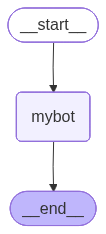

In [14]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [15]:
input={"messages":["hi hello how are you?"]}

In [16]:
app.invoke(input)

{'messages': [HumanMessage(content='hi hello how are you?', additional_kwargs={}, response_metadata={}, id='2ee9d0c2-f930-41d3-88cc-711eb90b4ba1'),
  AIMessage(content="Hello! I'm just a language model, I don't have feelings or emotions like humans do, but I'm functioning properly and ready to help with any questions or tasks you have. How can I assist you today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 42, 'prompt_tokens': 16, 'total_tokens': 58, 'completion_time': 0.043321168, 'prompt_time': 0.000271297, 'queue_time': 0.052515323, 'total_time': 0.043592465}, 'model_name': 'meta-llama/llama-4-maverick-17b-128e-instruct', 'system_fingerprint': 'fp_d2c1f7e199', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--61adfc25-2267-4410-b4de-848eea9b30d6-0', usage_metadata={'input_tokens': 16, 'output_tokens': 42, 'total_tokens': 58})]}

In [17]:
for output in app.stream(input):
    for key,value in output.items():
        print(f"Output from {key} Node")
        print("_______")
        print(value)
        print("\n")

Output from mybot Node
_______
{'messages': [AIMessage(content="I'm just a language model, I don't have feelings or emotions like humans do, but I'm functioning properly and ready to help with any questions or tasks you might have! How about you, how's your day going?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 16, 'total_tokens': 60, 'completion_time': 0.059394594, 'prompt_time': 0.000233977, 'queue_time': 0.052598683, 'total_time': 0.059628571}, 'model_name': 'meta-llama/llama-4-maverick-17b-128e-instruct', 'system_fingerprint': 'fp_d2c1f7e199', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--a3b82063-2907-4455-8aa8-99587eabbb81-0', usage_metadata={'input_tokens': 16, 'output_tokens': 44, 'total_tokens': 60})]}




### this is a workflow with tool calling

In [18]:
@tool
def search(query:str):
    """this is my custom tool for searching a weather"""
    if "delhi" in query.lower():
        return "the temp is 45 degree and sunny"
    return "the temp is 25 degree and cloudy"

## testing a tool

In [19]:
search.invoke("what is a tempurature in kashmir?")

'the temp is 25 degree and cloudy'

In [20]:
search.invoke("what is a tempurature in delhi?")

'the temp is 45 degree and sunny'

In [21]:
search

StructuredTool(name='search', description='this is my custom tool for searching a weather', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x0000025FCE8149A0>)

In [22]:
llm.invoke("what is a weather in delhi?")

AIMessage(content="Delhi, the capital city of India, has a humid subtropical climate with significant variations in temperature and weather conditions throughout the year. Here's a general overview of the weather in Delhi:\n\n**Seasons:**\n\n1. **Winter (December to February)**: Winters in Delhi are cool and foggy, with average temperatures ranging from 8°C to 15°C (46°F to 59°F). It can get quite chilly, especially in January, which is the coldest month.\n2. **Summer (March to May)**: Summers are hot and dry, with temperatures often soaring above 40°C (104°F). April and May are the hottest months, with average highs around 42°C (108°F).\n3. **Monsoon (June to September)**: Delhi experiences a monsoon season, with significant rainfall and high humidity. July and August are the wettest months, with average rainfall of around 200 mm (7.9 in) each.\n4. **Post-Monsoon (October to November)**: The post-monsoon season is characterized by pleasant weather, with comfortable temperatures and re

### Binding a tool to the LLM

### Special Note: use some good for agentic workflow since opensource model might not give you the correct output

In [23]:
tools=[search]

In [24]:
llm_with_tool=llm.bind_tools(tools)

### testig my llm_with_tool

In [25]:
response=llm_with_tool.invoke("what is a weather is delhi?")

In [26]:
response

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'veks12pxt', 'function': {'arguments': '{"query":"delhi weather"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 715, 'total_tokens': 745, 'completion_time': 0.046424679, 'prompt_time': 0.013486019, 'queue_time': 0.051530401, 'total_time': 0.059910698}, 'model_name': 'meta-llama/llama-4-maverick-17b-128e-instruct', 'system_fingerprint': 'fp_d2c1f7e199', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--8cc2730d-610d-4d30-8a54-b50213f9bcb4-0', tool_calls=[{'name': 'search', 'args': {'query': 'delhi weather'}, 'id': 'veks12pxt', 'type': 'tool_call'}], usage_metadata={'input_tokens': 715, 'output_tokens': 30, 'total_tokens': 745})

In [27]:
response.content

''

In [28]:
response.tool_calls

[{'name': 'search',
  'args': {'query': 'delhi weather'},
  'id': 'veks12pxt',
  'type': 'tool_call'}]

In [29]:
def call_model(state:MessagesState):
    question=state["messages"]
    response=llm_with_tool.invoke(question)
    return {"messages":[response]}

### Testing code

In [35]:
input={"messages":["Hi"]}
response=call_model(input)
response["messages"][-1].tool_calls
response["messages"][-1].content

'Hi, how can I assist you today?'

In [37]:
bool(["a"])

True

In [ ]:
input={"messages":["what is a weather in delhi?"]}

In [31]:
response=call_model(input)

In [32]:
response["messages"][-1].content

''

In [33]:
response["messages"][-1].tool_calls

[{'name': 'search',
  'args': {'query': 'delhi weather'},
  'id': 'qp10fnjp4',
  'type': 'tool_call'}]

### here my router function

#### now whatever will come from call_model router funtion will redirect this to the appropriate tool

In [38]:
def router_function(state:MessagesState):
    message=state["messages"]
    last_message=message[-1]
    if last_message.tool_calls:
        return "tools"
    return END
    

In [39]:
tools

[StructuredTool(name='search', description='this is my custom tool for searching a weather', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x0000025FCE8149A0>)]

In [41]:
tools

[StructuredTool(name='search', description='this is my custom tool for searching a weather', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x0000025FCE8149A0>)]

In [42]:

tool_node=ToolNode(tools)

In [43]:
tool_node

tools(tags=None, recurse=True, explode_args=False, func_accepts={'config': ('N/A', <class 'inspect._empty'>), 'store': ('store', None)}, tools_by_name={'search': StructuredTool(name='search', description='this is my custom tool for searching a weather', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x0000025FCE8149A0>)}, tool_to_state_args={'search': {}}, tool_to_store_arg={'search': None}, handle_tool_errors=True, messages_key='messages')

In [44]:
workflow2=StateGraph(MessagesState)

In [45]:
workflow2.add_node("llmwithtool",call_model)

workflow2.add_node("mytools",tool_node)

workflow2.add_edge(START,"llmwithtool")

workflow2.add_conditional_edges("llmwithtool",
                                router_function,
                                {"tools":"mytools",
                                 END:END})


In [46]:
app2=workflow2.compile()

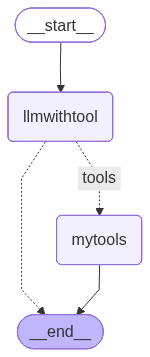

In [47]:
from IPython.display import Image, display
display(Image(app2.get_graph().draw_mermaid_png()))

In [48]:
response=app2.invoke({"messages":["what is a weather in bengaluru?"]})

In [50]:
response["messages"][-1].content

'the temp is 25 degree and cloudy'

In [51]:
app2.invoke({"messages":["what is a weather in delhi?"]})

{'messages': [HumanMessage(content='what is a weather in delhi?', additional_kwargs={}, response_metadata={}, id='e1ccf1db-70f0-47c4-9663-06d62ac199f1'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '3kbtfcmdv', 'function': {'arguments': '{"query":"delhi weather"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 715, 'total_tokens': 745, 'completion_time': 0.040491439, 'prompt_time': 0.018293556, 'queue_time': 0.053442563, 'total_time': 0.058784995}, 'model_name': 'meta-llama/llama-4-maverick-17b-128e-instruct', 'system_fingerprint': 'fp_d2c1f7e199', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--f6340cc4-44bd-4b36-8639-80ac277da544-0', tool_calls=[{'name': 'search', 'args': {'query': 'delhi weather'}, 'id': '3kbtfcmdv', 'type': 'tool_call'}], usage_metadata={'input_tokens': 715, 'output_tokens': 30, 'total_tokens': 745}),
  ToolMessage(content='the temp 

### use good resoning based model

In [48]:
app2.invoke({"messages":["hi how are you?"]})

{'messages': [HumanMessage(content='hi how are you?', additional_kwargs={}, response_metadata={}, id='69d2a9da-7d97-497e-9773-bddb3795bf4b'),
  AIMessage(content="I'm doing well, thank you for asking! I'm a large language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to help with any questions or tasks you might have.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 712, 'total_tokens': 756, 'completion_time': 0.065067784, 'prompt_time': 0.016683143, 'queue_time': 0.051230996, 'total_time': 0.081750927}, 'model_name': 'meta-llama/llama-4-maverick-17b-128e-instruct', 'system_fingerprint': 'fp_d2c1f7e199', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--770fd4ed-605e-48ef-9312-38a6e8125762-0', usage_metadata={'input_tokens': 712, 'output_tokens': 44, 'total_tokens': 756})]}

In [52]:
workflow2.add_edge("mytools","llmwithtool")

Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [53]:
app3=workflow2.compile()

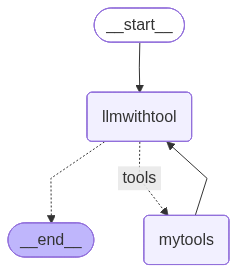

In [54]:
from IPython.display import Image, display
display(Image(app3.get_graph().draw_mermaid_png()))

In [55]:
for output in app3.stream({"messages":["what is a weather in new delhi?"]}):
    for key,value in output.items():
        print(f"here is output from {key}")
        print("_______")
        print(value)
        print("\n")
    

here is output from llmwithtool
_______
{'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'baj267q0e', 'function': {'arguments': '{"query":"new delhi weather"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 716, 'total_tokens': 747, 'completion_time': 0.045840478, 'prompt_time': 0.013798275, 'queue_time': 0.051085235, 'total_time': 0.059638753}, 'model_name': 'meta-llama/llama-4-maverick-17b-128e-instruct', 'system_fingerprint': 'fp_d2c1f7e199', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--4fef779d-495c-43fa-87d0-030cebafd55f-0', tool_calls=[{'name': 'search', 'args': {'query': 'new delhi weather'}, 'id': 'baj267q0e', 'type': 'tool_call'}], usage_metadata={'input_tokens': 716, 'output_tokens': 31, 'total_tokens': 747})]}


here is output from mytools
_______
{'messages': [ToolMessage(content='the temp is 45 degree and sunny', name='search', id=

In [56]:
from langgraph.checkpoint.memory import MemorySaver

In [57]:
memory=MemorySaver()

In [58]:
workflow3=StateGraph(MessagesState)

workflow3.add_node("llmwithtool",call_model)

workflow3.add_node("mytools",tool_node)

workflow3.add_edge(START,"llmwithtool")

workflow3.add_conditional_edges("llmwithtool",
                                router_function,
                                {"tools":"mytools",
                                 END:END})

workflow3.add_edge("mytools","llmwithtool")

In [59]:
app4=workflow3.compile(checkpointer=memory)

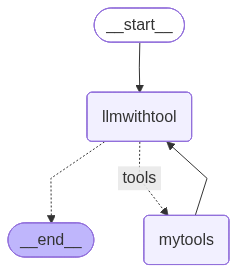

In [60]:
from IPython.display import Image, display
display(Image(app4.get_graph().draw_mermaid_png()))

In [61]:
config={"configurable": {"thread_id": "1"}}

In [62]:
events=app4.stream(
    {"messages":["what is a weather in new delhi?"]},config=config,stream_mode="values"
    )

In [63]:
for event in events:
    event["messages"][-1].pretty_print()
    

================================ Human Message =================================

what is a weather in new delhi?
================================== Ai Message ==================================
Tool Calls:
  search (8kjp53jrt)
 Call ID: 8kjp53jrt
  Args:
    query: new delhi weather
================================= Tool Message =================================
Name: search

the temp is 45 degree and sunny
================================== Ai Message ==================================

The temperature in New Delhi is 45 degrees and it's sunny.


In [64]:
events=app4.stream(
    {"messages":["what is a weather in indore?"]},config=config,stream_mode="values"
    )

In [65]:
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

what is a weather in indore?
================================== Ai Message ==================================
Tool Calls:
  search (xjjy6mn9c)
 Call ID: xjjy6mn9c
  Args:
    query: indore weather
================================= Tool Message =================================
Name: search

the temp is 25 degree and cloudy
================================== Ai Message ==================================

The temperature in Indore is 25 degrees and it's cloudy.


In [66]:
config

{'configurable': {'thread_id': '1'}}

In [67]:
memory.get(config)

{'v': 4,
 'ts': '2025-10-26T06:41:19.155459+00:00',
 'id': '1f0b236c-7620-6b3b-8008-ba94066a7539',
 'channel_versions': {'__start__': '00000000000000000000000000000007.0.7867469819514168',
  'messages': '00000000000000000000000000000010.0.3465353667517046',
  'branch:to:llmwithtool': '00000000000000000000000000000010.0.3465353667517046',
  'branch:to:mytools': '00000000000000000000000000000009.0.8234422565584442'},
 'versions_seen': {'__input__': {},
  '__start__': {'__start__': '00000000000000000000000000000006.0.13360205135948355'},
  'llmwithtool': {'branch:to:llmwithtool': '00000000000000000000000000000009.0.8234422565584442'},
  'mytools': {'branch:to:mytools': '00000000000000000000000000000008.0.7410253108705893'}},
 'updated_channels': ['messages'],
 'channel_values': {'messages': [HumanMessage(content='what is a weather in new delhi?', additional_kwargs={}, response_metadata={}, id='340a386b-af5a-40f4-a42f-84b547fc23b7'),
   AIMessage(content='', additional_kwargs={'tool_calls'

In [68]:
events=app4.stream(
    {"messages":["in which city the temp was 25 degree?"]},config=config,stream_mode="values"
    )

In [69]:
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

in which city the temp was 25 degree?
================================== Ai Message ==================================

The temperature was 25 degrees in Indore.


In [70]:
memory.get(config)

{'v': 4,
 'ts': '2025-10-26T06:41:53.128103+00:00',
 'id': '1f0b236d-ba1d-6e99-800b-5a24547353b9',
 'channel_versions': {'__start__': '00000000000000000000000000000012.0.42899911194913387',
  'messages': '00000000000000000000000000000013.0.5471358698680722',
  'branch:to:llmwithtool': '00000000000000000000000000000013.0.5471358698680722',
  'branch:to:mytools': '00000000000000000000000000000009.0.8234422565584442'},
 'versions_seen': {'__input__': {},
  '__start__': {'__start__': '00000000000000000000000000000011.0.06950572988366643'},
  'llmwithtool': {'branch:to:llmwithtool': '00000000000000000000000000000012.0.42899911194913387'},
  'mytools': {'branch:to:mytools': '00000000000000000000000000000008.0.7410253108705893'}},
 'updated_channels': ['messages'],
 'channel_values': {'messages': [HumanMessage(content='what is a weather in new delhi?', additional_kwargs={}, response_metadata={}, id='340a386b-af5a-40f4-a42f-84b547fc23b7'),
   AIMessage(content='', additional_kwargs={'tool_call